# Exploratory Data Analysis — Health Insurance Cross-Sell

**Goal:** Understand which customer attributes drive cross-sell conversion (`Response=1`), identify class imbalance, and surface features likely to matter in modeling.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, clean

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)
sns.set_theme(style="whitegrid", palette="muted")

df_raw = load_raw("../data/raw")
df     = clean(df_raw)

Loaded: 381,109 rows x 12 columns
Cleaned shape: (381109, 12) | missing values: 0


## 1. Dataset Overview

In [2]:
print(f"Shape: {df.shape}")
df.head()

Shape: (381109, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28,0,2,1,40454.0,26,217,1
1,2,1,76,1,3,0,1,0,33536.0,26,183,0
2,3,1,47,1,28,0,2,1,38294.0,26,27,1
3,4,1,21,1,11,1,0,0,28619.0,152,203,0
4,5,0,29,1,41,1,0,0,27496.0,152,39,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,381109.0,190555.000000,110016.836208,1.0,95278.0,190555.0,285832.0,381109.0
Gender,381109.0,0.540761,0.498336,0.0,0.0,1.0,1.0,1.0
Age,381109.0,38.822584,15.511611,20.0,25.0,36.0,49.0,85.0
Driving_License,381109.0,0.997869,0.046110,0.0,1.0,1.0,1.0,1.0
Region_Code,381109.0,26.388807,13.229888,0.0,15.0,28.0,35.0,52.0
Previously_Insured,381109.0,0.458210,0.498251,0.0,0.0,0.0,1.0,1.0
Vehicle_Age,381109.0,0.609616,0.567439,0.0,0.0,1.0,1.0,2.0
Vehicle_Damage,381109.0,0.504877,0.499977,0.0,0.0,1.0,1.0,1.0
Annual_Premium,381109.0,30564.389581,17213.155057,2630.0,24405.0,31669.0,39400.0,540165.0
Policy_Sales_Channel,381109.0,112.034295,54.203995,1.0,29.0,133.0,152.0,163.0


## 2. Target Distribution (Class Imbalance)

Response
0    334399
1     46710
Name: count, dtype: int64

Positive rate: 12.3%


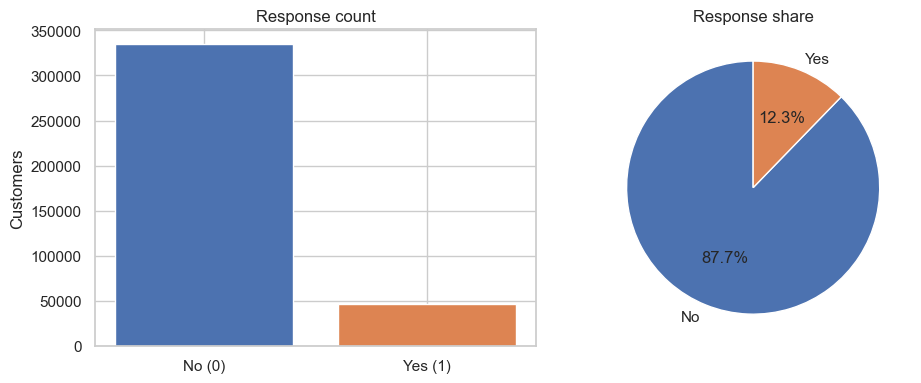

In [4]:
counts = df["Response"].value_counts()
print(counts)
print(f"\nPositive rate: {counts[1] / len(df):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["No (0)", "Yes (1)"], counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Response count")
axes[0].set_ylabel("Customers")

axes[1].pie(counts.values, labels=["No", "Yes"], autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Response share")
plt.tight_layout()

## 3. Conversion Rate by Key Categorical Features

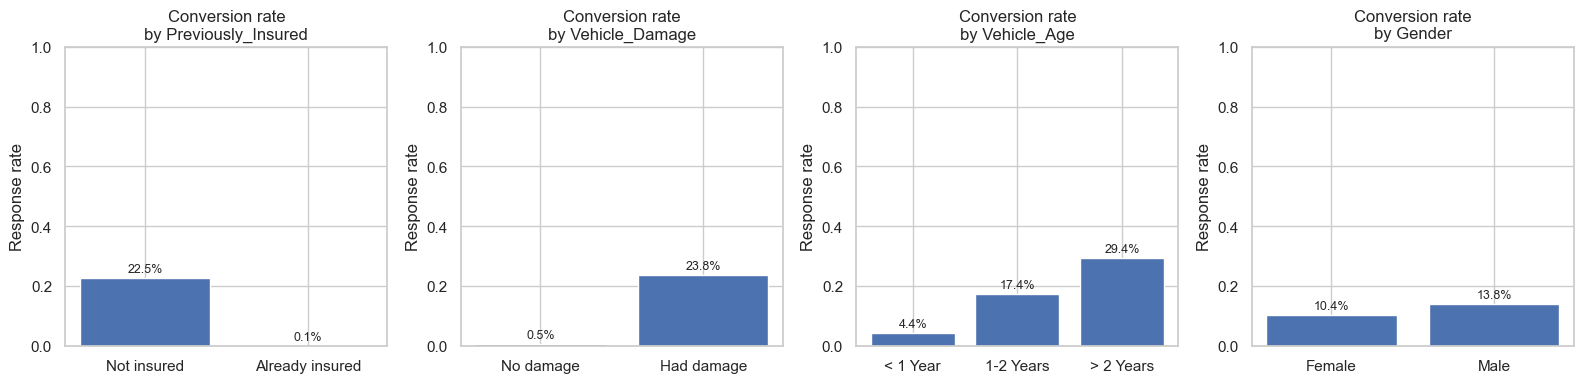

In [5]:
cat_features = {
    "Previously_Insured": {0: "Not insured", 1: "Already insured"},
    "Vehicle_Damage":     {0: "No damage",   1: "Had damage"},
    "Vehicle_Age":        {0: "< 1 Year",    1: "1-2 Years",  2: "> 2 Years"},
    "Gender":             {0: "Female",      1: "Male"},
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (col, label_map) in zip(axes, cat_features.items()):
    conv = df.groupby(col)["Response"].mean().reset_index()
    conv[col] = conv[col].map(label_map)
    ax.bar(conv[col], conv["Response"], color="#4C72B0")
    ax.set_title(f"Conversion rate\nby {col}")
    ax.set_ylabel("Response rate")
    ax.set_ylim(0, 1)
    for i, v in enumerate(conv["Response"]):
        ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()

## 4. Age Distribution by Response

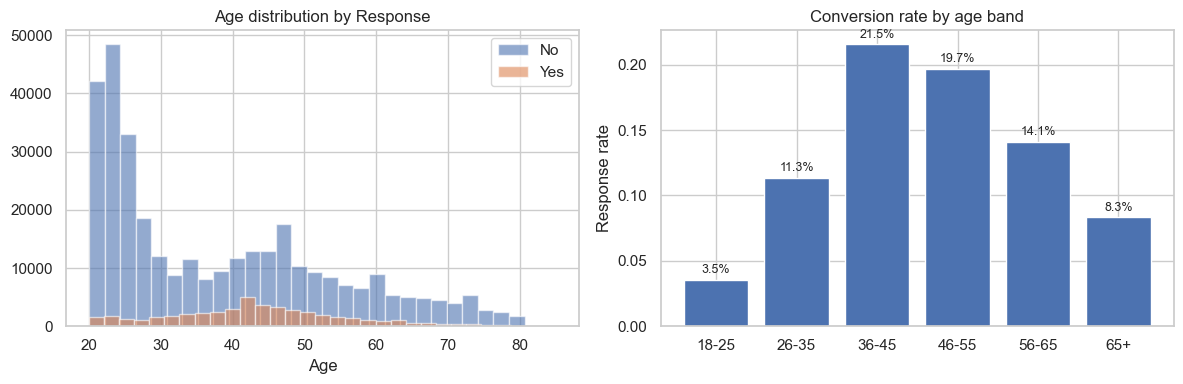

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
for resp, label, color in [(0, "No", "#4C72B0"), (1, "Yes", "#DD8452")]:
    axes[0].hist(df[df["Response"] == resp]["Age"], bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title("Age distribution by Response")
axes[0].set_xlabel("Age")
axes[0].legend()

# Conversion rate by age band
df["age_band"] = pd.cut(df["Age"], bins=[18, 25, 35, 45, 55, 65, 85],
                        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])
conv_age = df.groupby("age_band", observed=True)["Response"].mean()
axes[1].bar(conv_age.index.astype(str), conv_age.values, color="#4C72B0")
axes[1].set_title("Conversion rate by age band")
axes[1].set_ylabel("Response rate")
for i, v in enumerate(conv_age.values):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=9)

df.drop(columns=["age_band"], inplace=True)
plt.tight_layout()

## 5. Annual Premium Distribution

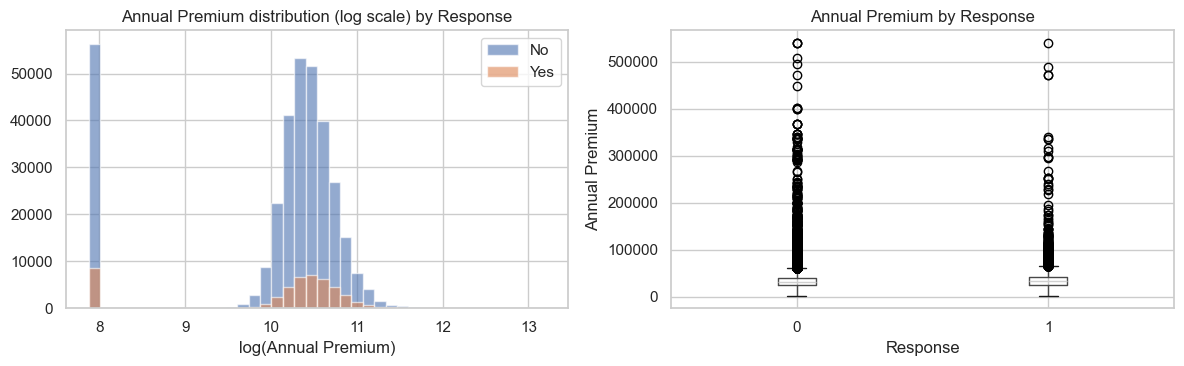

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Log scale for premium (heavy right skew)
for resp, label, color in [(0, "No", "#4C72B0"), (1, "Yes", "#DD8452")]:
    axes[0].hist(np.log1p(df[df["Response"] == resp]["Annual_Premium"]),
                 bins=40, alpha=0.6, label=label, color=color)
axes[0].set_title("Annual Premium distribution (log scale) by Response")
axes[0].set_xlabel("log(Annual Premium)")
axes[0].legend()

# Boxplot
df.boxplot(column="Annual_Premium", by="Response", ax=axes[1])
axes[1].set_title("Annual Premium by Response")
axes[1].set_xlabel("Response")
axes[1].set_ylabel("Annual Premium")
plt.suptitle("")
plt.tight_layout()

## 6. Vintage (Days as Customer) vs Response

Vintage has roughly uniform conversion — low predictive signal on its own.


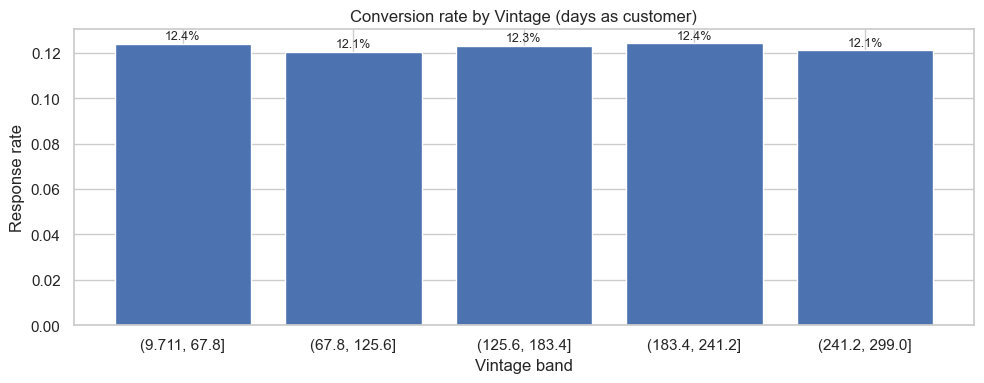

In [8]:
df["vintage_band"] = pd.cut(df["Vintage"], bins=5)
conv_vintage = df.groupby("vintage_band", observed=True)["Response"].mean()

plt.figure(figsize=(10, 4))
plt.bar(conv_vintage.index.astype(str), conv_vintage.values, color="#4C72B0")
plt.title("Conversion rate by Vintage (days as customer)")
plt.xlabel("Vintage band")
plt.ylabel("Response rate")
for i, v in enumerate(conv_vintage.values):
    plt.text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=9)
plt.tight_layout()

df.drop(columns=["vintage_band"], inplace=True)

print("Vintage has roughly uniform conversion — low predictive signal on its own.")

## 7. Correlation Heatmap

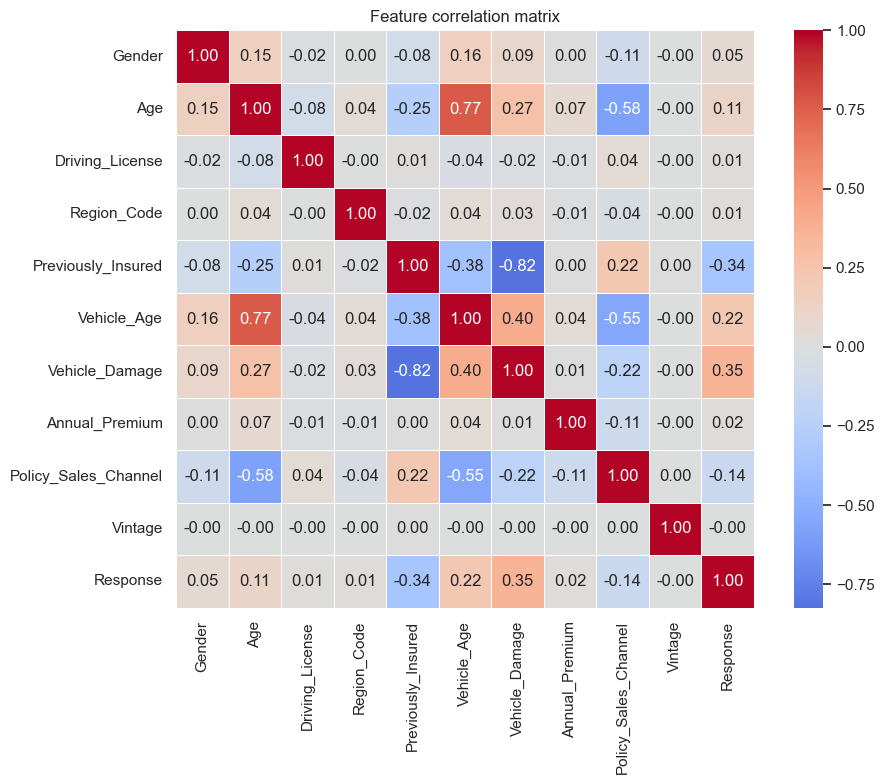

In [9]:
feature_cols = [c for c in df.columns if c != "id"]
corr = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Feature correlation matrix")
plt.tight_layout()

## 8. Top Correlations with Response

Feature correlations with Response:

Vehicle_Damage          0.354400
Previously_Insured     -0.341170
Vehicle_Age             0.221874
Policy_Sales_Channel   -0.139042
Age                     0.111147
Gender                  0.052440
Annual_Premium          0.022575
Region_Code             0.010570
Driving_License         0.010155
Vintage                -0.001050


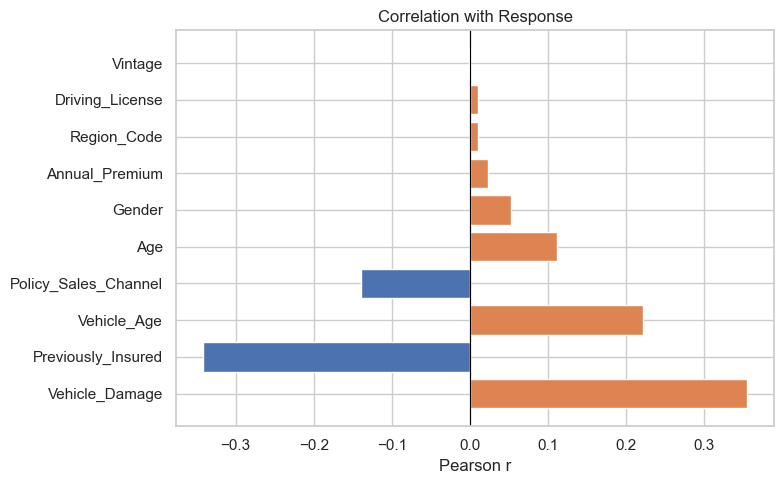

In [10]:
response_corr = corr["Response"].drop("Response").sort_values(key=abs, ascending=False)
print("Feature correlations with Response:\n")
print(response_corr.to_string())

plt.figure(figsize=(8, 5))
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in response_corr.values]
plt.barh(response_corr.index, response_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation with Response")
plt.xlabel("Pearson r")
plt.tight_layout()

## 9. Policy Sales Channel — Top Channels by Volume and Conversion

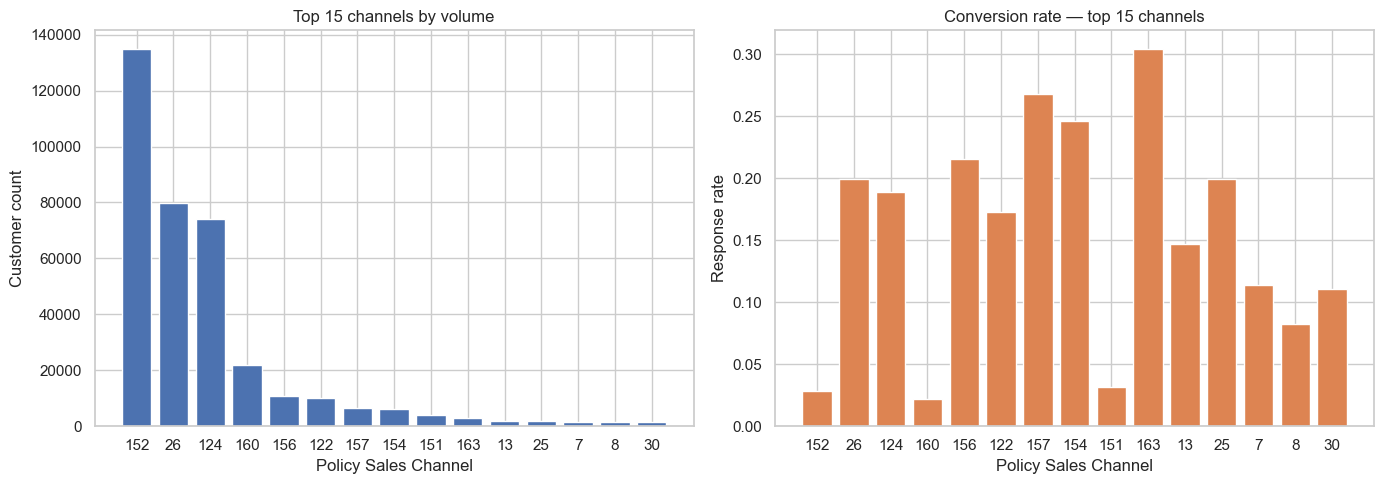

In [11]:
channel_stats = (
    df.groupby("Policy_Sales_Channel")
    .agg(count=("Response", "count"), conversion=("Response", "mean"))
    .sort_values("count", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(channel_stats.index.astype(str), channel_stats["count"], color="#4C72B0")
axes[0].set_title("Top 15 channels by volume")
axes[0].set_xlabel("Policy Sales Channel")
axes[0].set_ylabel("Customer count")

axes[1].bar(channel_stats.index.astype(str), channel_stats["conversion"], color="#DD8452")
axes[1].set_title("Conversion rate — top 15 channels")
axes[1].set_xlabel("Policy Sales Channel")
axes[1].set_ylabel("Response rate")

plt.tight_layout()

## 10. Key Takeaways for Feature Engineering

In [12]:
"""
Key findings:

1. CLASS IMBALANCE: ~12.3% positive rate — need scale_pos_weight in XGBoost
   and PR-AUC as primary metric (not accuracy).

2. STRONGEST SIGNALS:
   - Previously_Insured=0 → high conversion; =1 → near-zero (already have it)
   - Vehicle_Damage=Yes → much higher conversion
   - Vehicle_Age: older vehicles → higher conversion (> 2 Years highest)

3. AGE: Non-linear. 35-55 age band converts highest. Young (<25) and old (65+) convert less.

4. ANNUAL PREMIUM: Converters tend to pay slightly higher premiums — modest signal.

5. VINTAGE: Nearly flat across bands — low standalone signal.
   May combine with other features for interactions.

6. POLICY SALES CHANNEL: High variance across channels — frequency encode top channels,
   bucket low-volume channels as "other".

7. NO MISSING VALUES — clean dataset, no imputation needed.

Feature engineering plan:
  - Keep all raw features (all are informative)
  - Add: premium_log (log1p transform for skew)
  - Add: channel_freq (frequency encoding of Policy_Sales_Channel)
  - Add: region_freq (frequency encoding of Region_Code)
  - Add: age_x_vehicle_damage (interaction — young driver + damage)
  - Add: not_insured_x_damage (Previously_Insured=0 AND Vehicle_Damage=1)
"""
print("EDA complete. See comments above for feature engineering plan.")

EDA complete. See comments above for feature engineering plan.
